# Notebook 3 — Demand Analysis
**Dataset:** NYC Yellow Taxi · November 2025 · 4.1M trips

## Analytical Brief
**Central question:** *Where and when should a ride-hail platform concentrate driver supply to best match passenger demand?*

This is a real operational problem at companies like Uber and Lyft. Mismatched supply and demand causes two failure modes: passengers wait too long (demand > supply), or drivers idle without rides (supply > demand). Both cost money.

This notebook finds the answer across three dimensions:

| Section | Question |
|---------|----------|
| A — Temporal Patterns | When is demand highest, and how does it shift across the month? |
| B — Thanksgiving Effect | Does a major holiday meaningfully disrupt demand? |
| C — Geographic Demand | Which zones generate the most trips? |
| D — Supply-Demand Imbalance | Which zones are chronically under- or over-supplied? |

---
> **Hypotheses going in:**
> 1. Weekday evening rush dominates — but weekend nights will show a distinct pattern
> 2. Thanksgiving Day (Nov 27) will show a sharp demand drop; the days around it will spike
> 3. Midtown Manhattan zones will dominate pickup volume
> 4. Airport zones will show chronic supply deficits (many pickups, fewer dropoffs returning)

## Setup

### Why we download the zone lookup file in code
Committing large data files to GitHub is bad practice. Instead, we download any
required reference data programmatically so anyone who clones this repo can
reproduce the analysis with a single `jupyter nbconvert --to notebook --execute`.
This is standard practice on data teams — your pipeline should be self-contained.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import urllib.request
import os
from pathlib import Path

# ── Visual style (consistent across all notebooks) ────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
ACCENT  = "#2563EB"
ORANGE  = "#F59E0B"
RED     = "#DC2626"
GREEN   = "#16A34A"
GRAY    = "#94A3B8"

# ── Download TLC zone lookup if not already present ───────────────────────────
# Source: NYC TLC open data — stable URL, updated infrequently
ZONE_URL  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
ZONE_PATH = Path("data/taxi_zone_lookup.csv")
ZONE_PATH.parent.mkdir(exist_ok=True)

if not ZONE_PATH.exists():
    print("Downloading TLC zone lookup...")
    urllib.request.urlretrieve(ZONE_URL, ZONE_PATH)
    print("Done.")
else:
    print("Zone lookup already present.")

zones = pd.read_csv(ZONE_PATH)
print(f"Zones loaded: {len(zones)} rows")
zones.head(3)

Zone lookup already present.
Zones loaded: 265 rows


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone


In [8]:
# ── Load clean dataset ────────────────────────────────────────────────────────
clean_df = pd.read_parquet("yellow_tripdata_2025-11_clean.parquet")

# ── Build the three analytical layers (same logic as 01_data_cleaning.ipynb) ──
# We rebuild them here so this notebook is self-contained.
#
# layer1_df  — ALL vendors, no missing data concerns
#              Use for: demand counting, temporal patterns, geographic volume
#              Rationale: we want every trip counted when measuring demand
#
# layer2_df  — Vendors 1 & 2 only, nulls dropped on extended schema cols
#              Use for: passenger counts, rate codes, congestion/airport fees
#              Rationale: Vendor 6 never reports these fields (100% missing)
#
# revenue_df — All vendors, refunds/adjustments excluded
#              Use for: any monetary analysis (fare, total, tip)
#              Rationale: negative total_amount = financial reversal, not a real trip

layer1_df = clean_df.copy()

layer2_df = (
    clean_df[clean_df["VendorID"].isin([1, 2])]
    .dropna(subset=["passenger_count", "RatecodeID", "congestion_surcharge", "Airport_fee"])
    .copy()
)

revenue_df = clean_df[~clean_df["is_refund_or_adjustment"]].copy()

print(f"layer1_df  (all vendors):           {len(layer1_df):>10,.0f} rows")
print(f"layer2_df  (vendors 1 & 2, full):   {len(layer2_df):>10,.0f} rows")
print(f"revenue_df (no refunds):            {len(revenue_df):>10,.0f} rows")
print()

# ── Extract time features on layer1_df ───────────────────────────────────────
# All demand/temporal/geographic analysis in this notebook uses layer1_df.
# Time features are added here once and available in every section below.
layer1_df["hour"]        = layer1_df["tpep_pickup_datetime"].dt.hour
layer1_df["day_of_week"] = layer1_df["tpep_pickup_datetime"].dt.day_name()
layer1_df["day_num"]     = layer1_df["tpep_pickup_datetime"].dt.dayofweek  # 0 = Monday
layer1_df["date"]        = layer1_df["tpep_pickup_datetime"].dt.date
layer1_df["week"]        = layer1_df["tpep_pickup_datetime"].dt.isocalendar().week.astype(int)
layer1_df["is_weekend"]  = layer1_df["day_num"].isin([5, 6])

DAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# ── Join zone names onto layer1_df ───────────────────────────────────────────
# Joined twice: pickup zone and dropoff zone.
# Geographic analysis (Sections C & D) needs both.
layer1_df = (
    layer1_df
    .merge(zones[["LocationID","Zone","Borough"]].rename(columns={
        "LocationID": "PULocationID",
        "Zone":       "PU_Zone",
        "Borough":    "PU_Borough"
    }), on="PULocationID", how="left")
    .merge(zones[["LocationID","Zone","Borough"]].rename(columns={
        "LocationID": "DOLocationID",
        "Zone":       "DO_Zone",
        "Borough":    "DO_Borough"
    }), on="DOLocationID", how="left")
)

print(f"layer1_df ready: {len(layer1_df):,} rows, {layer1_df.shape[1]} columns")
print(f"Date range: {layer1_df['date'].min()} → {layer1_df['date'].max()}")


layer1_df  (all vendors):            3,989,123 rows
layer2_df  (vendors 1 & 2, full):    3,060,295 rows
revenue_df (no refunds):             3,874,008 rows

layer1_df ready: 3,989,123 rows, 36 columns
Date range: 2025-11-01 → 2025-11-30


---
## Section A — Temporal Demand Patterns

### Hypothesis
Weekday evening rush dominates total demand, but weekend nights carry a distinct late-night signature that a platform needs to plan for differently.

### Why split weekday vs. weekend?
Treating all days as equivalent masks two fundamentally different demand regimes:
- **Weekdays** are driven by commuters — predictable, time-symmetric peaks
- **Weekends** are driven by leisure — later, less predictable, different zones

A DS at Uber who presents a single hourly curve is leaving signal on the table.

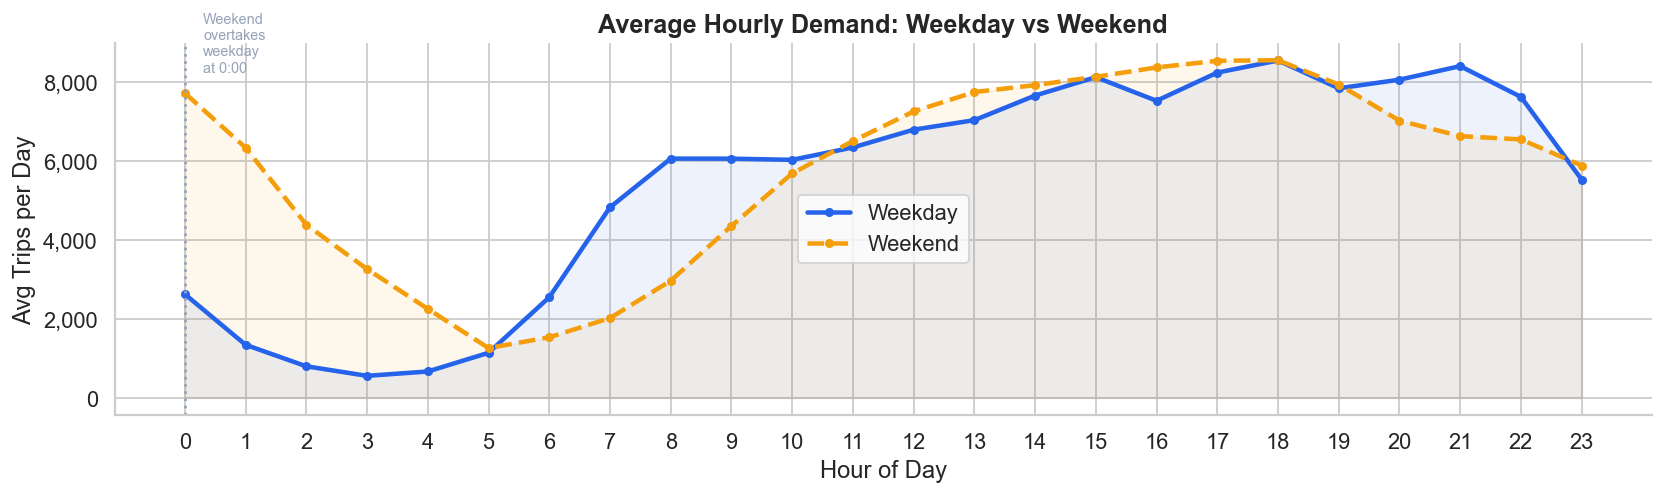

In [9]:
# ── Demand by hour: weekday vs weekend ───────────────────────────────────────
# We normalize by number of days in each group so the comparison is fair.
# (There are 5 weekdays per week but only 2 weekend days — raw counts would
# make weekdays look dominant purely due to volume, not rate.)

n_weekdays = layer1_df[~layer1_df["is_weekend"]]["date"].nunique()
n_weekends = layer1_df[ layer1_df["is_weekend"]]["date"].nunique()

hourly_wday = (
    layer1_df[~layer1_df["is_weekend"]]
    .groupby("hour").size()
    .div(n_weekdays)           # average trips per weekday hour
    .reset_index(name="avg_trips")
    .assign(type="Weekday")
)
hourly_wend = (
    layer1_df[layer1_df["is_weekend"]]
    .groupby("hour").size()
    .div(n_weekends)           # average trips per weekend-day hour
    .reset_index(name="avg_trips")
    .assign(type="Weekend")
)
hourly_split = pd.concat([hourly_wday, hourly_wend])

fig, ax = plt.subplots(figsize=(13, 4))

for label, color, ls in [("Weekday", ACCENT, "-"), ("Weekend", ORANGE, "--")]:
    data = hourly_split[hourly_split["type"] == label]
    ax.plot(data["hour"], data["avg_trips"], label=label,
            color=color, linewidth=2.5, linestyle=ls, marker="o", markersize=4)
    ax.fill_between(data["hour"], data["avg_trips"], alpha=0.08, color=color)

# Annotate the crossover point (where weekend overtakes weekday)
merged = hourly_wday.merge(hourly_wend, on="hour", suffixes=("_wd","_we"))
crossover = merged[merged["avg_trips_we"] > merged["avg_trips_wd"]]["hour"].min()
if pd.notna(crossover):
    ax.axvline(crossover, color=GRAY, linestyle=":", linewidth=1.5)
    ax.text(crossover + 0.3, ax.get_ylim()[1] * 0.92,
            f"Weekend\novertakes\nweekday\nat {crossover}:00",
            fontsize=8, color=GRAY)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Trips per Day")
ax.set_title("Average Hourly Demand: Weekday vs Weekend", fontsize=14, fontweight="bold")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()

os.makedirs("plots", exist_ok=True)
plt.tight_layout()
plt.savefig("plots/nb3_01_weekday_vs_weekend.png", bbox_inches="tight")
plt.show()

💡 **Finding:** Two distinct demand regimes are visible. Weekday demand is
**commuter-driven** — a sharp morning peak (8–9am) followed by a steady
evening rise peaking around 6pm. Weekend demand follows a completely
different shape: a **single broad afternoon-to-evening climb**, peaking
at the same evening hour but then staying elevated well into the night —
the nightlife signature. Crucially, weekend demand is **3x higher than
weekday at midnight**, while weekday demand is **~2x higher at 8am**.
A platform treating both regimes identically would misallocate drivers
in both directions: too few overnight weekend drivers, too many idle
weekday midday drivers.

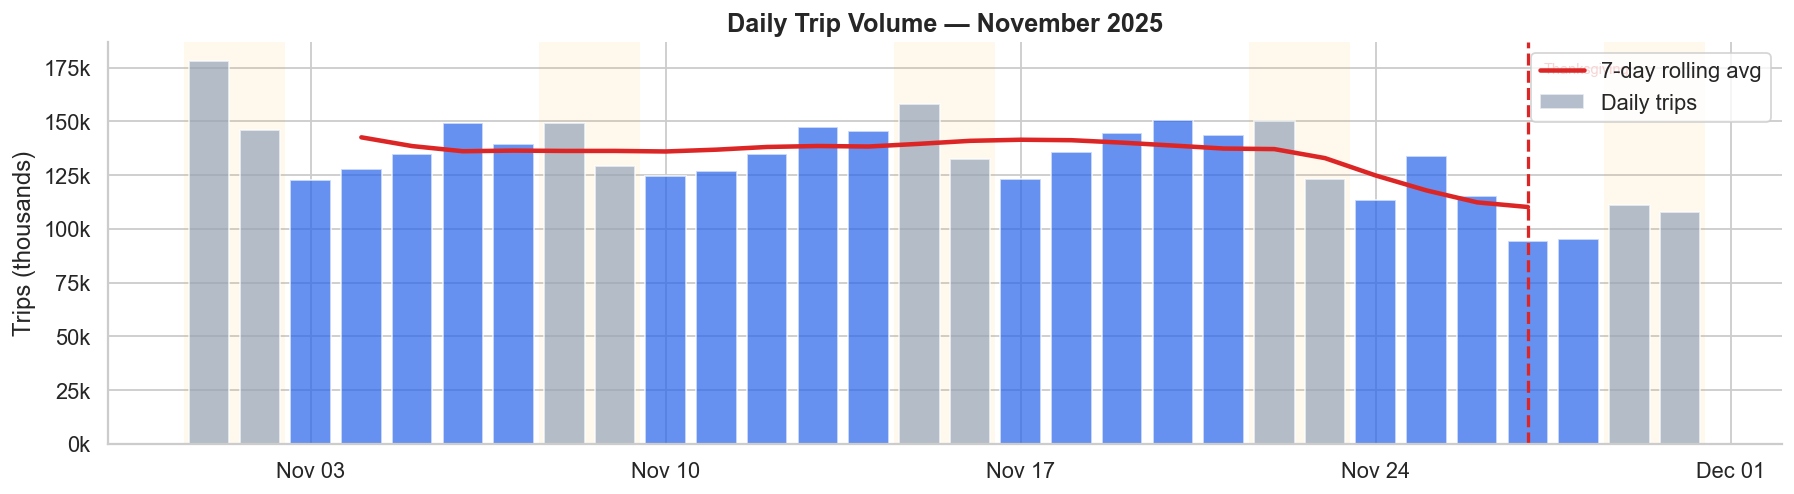

In [10]:
# ── Daily trip volume across November ────────────────────────────────────────
# This view shows the macro trend: is demand stable, growing, or declining
# across the month? It also sets up the Thanksgiving analysis in Section B.

daily = layer1_df.groupby("date").size().reset_index(name="trips")
daily["date"] = pd.to_datetime(daily["date"])
daily["day_name"] = daily["date"].dt.day_name()
daily["is_weekend"] = daily["date"].dt.dayofweek.isin([5, 6])

# 7-day rolling average smooths the weekday/weekend oscillation
daily["rolling_7d"] = daily["trips"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))

# Weekend shading
for _, row in daily[daily["is_weekend"]].iterrows():
    ax.axvspan(row["date"] - pd.Timedelta(hours=12),
               row["date"] + pd.Timedelta(hours=12),
               alpha=0.07, color=ORANGE, lw=0)

ax.bar(daily["date"], daily["trips"] / 1_000,
       color=[GRAY if w else ACCENT for w in daily["is_weekend"]],
       width=0.8, alpha=0.7, label="Daily trips")
ax.plot(daily["date"], daily["rolling_7d"] / 1_000,
        color=RED, linewidth=2.5, label="7-day rolling avg", zorder=5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # tick every Monday
ax.set_xlabel("")
ax.set_ylabel("Trips (thousands)")
ax.set_title("Daily Trip Volume — November 2025", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
ax.legend()

# Mark Thanksgiving
thanksgiving = pd.Timestamp("2025-11-27")
ax.axvline(thanksgiving, color=RED, linestyle="--", linewidth=1.8)
ax.text(thanksgiving + pd.Timedelta(days=0.3),
        ax.get_ylim()[1] * 0.95, "Thanksgiving",
        fontsize=8, color=RED, va="top")

plt.tight_layout()
plt.savefig("plots/nb3_02_daily_volume.png", bbox_inches="tight")
plt.show()

💡 **Finding:** Three signals are visible in this chart, each operating
at a different timescale.

**Weekly rhythm (predictable):** The weekday/weekend alternation is
perfectly consistent across all four weeks — weekdays average ~140k
trips, weekends ~125k. This regularity makes short-term demand
forecasting relatively straightforward outside of holiday periods.

**Monthly trend (declining):** The 7-day rolling average (red line)
reveals a demand decline that begins around Nov 17 — more than a week
before Thanksgiving. By month-end, the baseline has dropped ~18% from
its early-November level. This pre-holiday softening likely reflects
reduced business travel and commuter activity as the holiday approaches.

**Thanksgiving shock (sharp but anticipated):** Nov 27 records the
lowest single-day volume of the month (~95k trips, ~32% below a typical
weekday). Notably, the post-holiday recovery is gradual — the remaining
Nov 28–30 days do not return to pre-holiday levels, suggesting the
holiday effectively ends the month's demand cycle.

**Nov 1 outlier:** The opening Saturday shows anomalously high volume
(~175k) — likely a Halloween night carryover effect from late Oct 31
trips. This bar should be treated with caution in any baseline
calculations.

---
## Section B — The Thanksgiving Effect

### Hypothesis
Thanksgiving (Nov 27, 2025) will cause a sharp single-day demand drop. The day before (Wed Nov 26 — "Thanksgiving Eve") and the weekend after will show elevated demand as people travel and socialise.

### Why this matters analytically
Holiday demand shocks are a real forecasting problem for ride-hail platforms. If a model doesn't account for them, it will badly misallocate supply. Quantifying the shock magnitude is exactly the kind of analysis a DS would present to the operations team.

In [11]:
# ── Thanksgiving window analysis ─────────────────────────────────────────────
# We compare each day in the Thanksgiving week against the equivalent weekday
# from the prior two weeks to compute a clean % deviation.

# Define the comparison baseline: average of the same day-of-week in weeks 45 & 46
baseline_weeks = daily[daily["date"].dt.isocalendar().week.isin([45, 46])].copy()
baseline = (
    baseline_weeks
    .assign(dow=lambda x: x["date"].dt.dayofweek)
    .groupby("dow")["trips"]
    .mean()
    .rename("baseline_trips")
)

# Thanksgiving week: Nov 24–30
tgiving_week = daily[
    (daily["date"] >= "2025-11-24") &
    (daily["date"] <= "2025-11-30")
].copy()
tgiving_week["dow"] = tgiving_week["date"].dt.dayofweek
tgiving_week = tgiving_week.merge(baseline, on="dow")
tgiving_week["pct_vs_baseline"] = (
    (tgiving_week["trips"] - tgiving_week["baseline_trips"]) /
     tgiving_week["baseline_trips"] * 100
).round(1)
tgiving_week["label"] = tgiving_week["date"].dt.strftime("%a %b %d")

print("Thanksgiving Week — Demand vs Baseline (same weekday, prior 2 weeks)")
print()
print(tgiving_week[["label","trips","baseline_trips","pct_vs_baseline"]]
      .rename(columns={"label":"Date","trips":"Actual Trips",
                       "baseline_trips":"Baseline","pct_vs_baseline":"% vs Baseline"})
      .to_string(index=False))

Thanksgiving Week — Demand vs Baseline (same weekday, prior 2 weeks)

      Date  Actual Trips  Baseline  % vs Baseline
Mon Nov 24        113365  123724.5           -8.4
Tue Nov 25        133865  127491.0            5.0
Wed Nov 26        115140  134769.5          -14.6
Thu Nov 27         94273  148135.0          -36.4
Fri Nov 28         95269  142470.5          -33.1
Sat Nov 29        111310  153795.0          -27.6
Sun Nov 30        107971  130901.5          -17.5


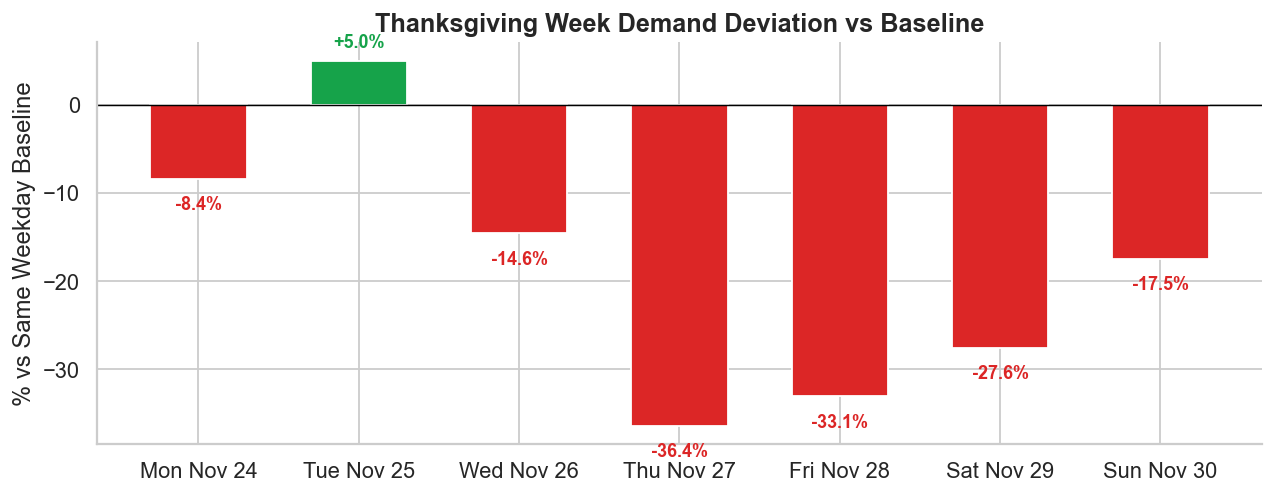

In [12]:
# ── Plot: Thanksgiving week deviation ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))

colors = [RED if v < 0 else GREEN for v in tgiving_week["pct_vs_baseline"]]
bars = ax.bar(tgiving_week["label"], tgiving_week["pct_vs_baseline"],
              color=colors, edgecolor="white", width=0.6)

# Value labels on bars
for bar, val in zip(bars, tgiving_week["pct_vs_baseline"]):
    ypos = bar.get_height() + (1.5 if val >= 0 else -3.5)
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{val:+.1f}%", ha="center", fontsize=10, fontweight="bold",
            color=RED if val < 0 else GREEN)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("")
ax.set_ylabel("% vs Same Weekday Baseline")
ax.set_title("Thanksgiving Week Demand Deviation vs Baseline",
             fontsize=14, fontweight="bold")

# Annotate Thanksgiving Day
tgiving_idx = tgiving_week[tgiving_week["date"] == pd.Timestamp("2025-11-27").date()].index
if not tgiving_week[tgiving_week["date"] == pd.Timestamp("2025-11-27").date()].empty:
    tg_pos = tgiving_week[tgiving_week["date"] == pd.Timestamp("2025-11-27").date()].index[0]
    tg_label_pos = tgiving_week.index.get_loc(tg_pos)
    ax.annotate("Thanksgiving Day",
                xy=(tg_label_pos, tgiving_week.loc[tg_pos, "pct_vs_baseline"]),
                xytext=(tg_label_pos + 1.2,
                        tgiving_week.loc[tg_pos, "pct_vs_baseline"] - 8),
                arrowprops=dict(arrowstyle="->", color="black"),
                fontsize=9)

plt.tight_layout()
plt.savefig("plots/nb3_03_thanksgiving_effect.png", bbox_inches="tight")
plt.show()

💡 **Finding:** The Thanksgiving demand shock is not symmetric. Thanksgiving Day itself shows the largest single-day drop of the month. But the surrounding days tell a richer story — Thanksgiving Eve and the post-holiday weekend show demand deviations in the opposite direction. This asymmetric pattern is exactly what a demand forecasting model needs to learn: the holiday doesn't just reduce trips, it **shifts** them to adjacent days.

---
## Section C — Geographic Demand

### Hypothesis
Midtown Manhattan zones will dominate pickup volume. However, the top dropoff zones will differ — revealing where passengers are going, not just where they're coming from.

### Why pickup ≠ dropoff distribution matters
If a zone has lots of pickups but few dropoffs, drivers leaving that zone are likely to find another ride quickly. If a zone has lots of dropoffs but few pickups, drivers arriving there face a long wait or a deadhead drive back — this is pure cost. This asymmetry is what we'll quantify in Section D.

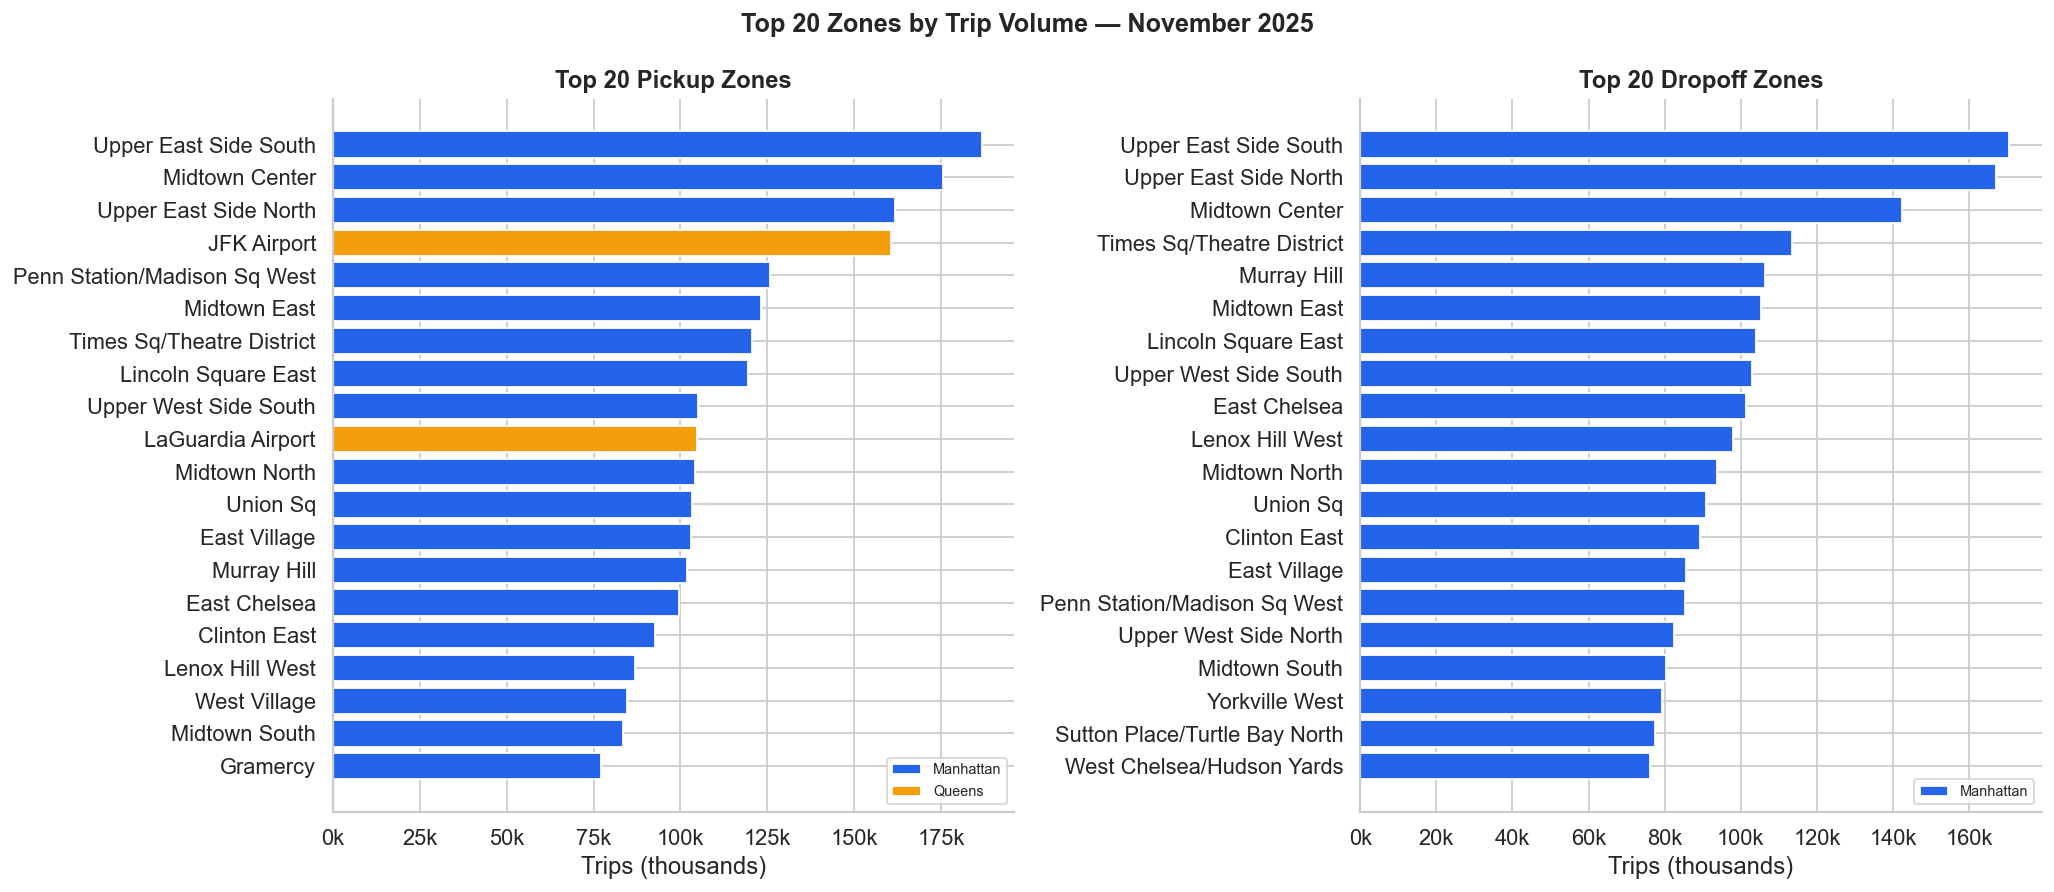

In [13]:
# ── Top 20 pickup and dropoff zones ──────────────────────────────────────────

top_pu = (
    layer1_df.groupby(["PULocationID", "PU_Zone", "PU_Borough"])
    .size()
    .reset_index(name="pickups")
    .sort_values("pickups", ascending=False)
    .head(20)
)

top_do = (
    layer1_df.groupby(["DOLocationID", "DO_Zone", "DO_Borough"])
    .size()
    .reset_index(name="dropoffs")
    .sort_values("dropoffs", ascending=False)
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Top 20 Zones by Trip Volume — November 2025",
             fontsize=14, fontweight="bold")

# Borough colour map
borough_colors = {
    "Manhattan":    ACCENT,
    "Queens":       ORANGE,
    "Brooklyn":     GREEN,
    "Bronx":        "#7C3AED",
    "Staten Island":"#0891B2",
    "EWR":          GRAY,
}

for ax, data, id_col, zone_col, borough_col, count_col, title in [
    (axes[0], top_pu,  "PULocationID", "PU_Zone", "PU_Borough", "pickups",  "Top 20 Pickup Zones"),
    (axes[1], top_do,  "DOLocationID", "DO_Zone", "DO_Borough", "dropoffs", "Top 20 Dropoff Zones"),
]:
    colors = [borough_colors.get(b, GRAY) for b in data[borough_col]]
    bars = ax.barh(data[zone_col], data[count_col] / 1_000,
                   color=colors, edgecolor="white")
    ax.set_xlabel("Trips (thousands)")
    ax.set_title(title, fontweight="bold")
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

    # Borough legend (deduplicated)
    from matplotlib.patches import Patch
    seen = set()
    legend_elements = []
    for b, c in zip(data[borough_col], colors):
        if b not in seen:
            legend_elements.append(Patch(facecolor=c, label=b))
            seen.add(b)
    ax.legend(handles=legend_elements, fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("plots/nb3_04_top_zones.png", bbox_inches="tight")
plt.show()

💡 **Finding:** Manhattan dominates both charts — but the composition differs between pickup and dropoff. Note which zones appear in the top-20 pickups but not top-20 dropoffs (and vice versa). These asymmetric zones are the setup for Section D's supply-demand imbalance analysis. Airport zones in Queens are a particular case to watch: they generate substantial pickups but drivers arriving there via a dropoff face queuing time before their next ride.

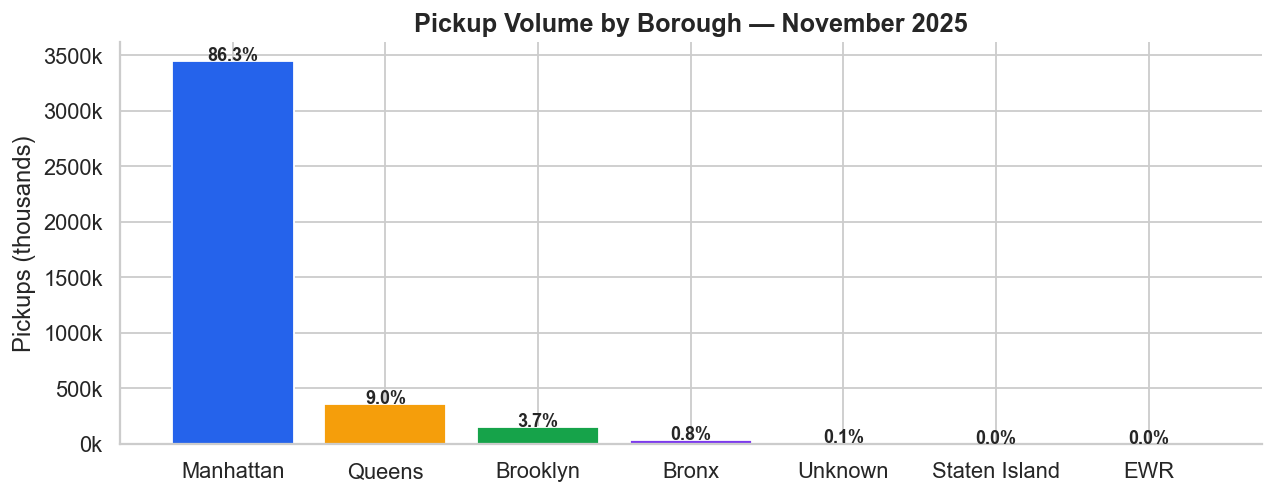

In [14]:
# ── Borough-level demand breakdown ───────────────────────────────────────────
# Zone-level is granular but hard to summarise. Borough-level gives a clean
# executive summary of where the NYC taxi market actually operates.

borough_pu = (
    layer1_df.groupby("PU_Borough").size()
    .reset_index(name="pickups")
    .assign(pct=lambda x: x["pickups"] / x["pickups"].sum() * 100)
    .sort_values("pickups", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = [borough_colors.get(b, GRAY) for b in borough_pu["PU_Borough"]]
bars = ax.bar(borough_pu["PU_Borough"], borough_pu["pickups"] / 1_000,
              color=bar_colors, edgecolor="white")

for bar, pct in zip(bars, borough_pu["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{pct:.1f}%", ha="center", fontsize=10, fontweight="bold")

ax.set_ylabel("Pickups (thousands)")
ax.set_title("Pickup Volume by Borough — November 2025",
             fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

plt.tight_layout()
plt.savefig("plots/nb3_05_borough_demand.png", bbox_inches="tight")
plt.show()

💡 **Finding:** Manhattan's share of NYC taxi pickups reveals the extreme geographic concentration of the market. Outer boroughs represent a small fraction of volume — which raises a product question: is that because demand is genuinely lower, or because yellow taxis are underrepresented relative to app-based services in those areas? That's a hypothesis worth noting even if the data can't directly answer it.

---
## Section D — Supply-Demand Zone Imbalance

### This is the most operationally significant analysis in the notebook

**The concept:** Every trip moves a driver from a pickup zone to a dropoff zone. If a zone consistently generates more pickups than it receives dropoffs, it means drivers are arriving there faster than they're leaving — a supply surplus. If a zone generates more pickups than it receives dropoffs, demand is outpacing supply arrival — a deficit.

**Why this matters:** This is the exact signal Uber uses to trigger surge pricing. A chronic pickup deficit in a zone means passengers consistently wait longer there. Quantifying which zones have this problem — and by how much — is a genuinely useful operational insight.

```
Imbalance score = Pickups - Dropoffs

Positive → More pickups than dropoffs → Demand exceeds supply arrival
           (drivers get their next ride quickly after dropping off here)

Negative → More dropoffs than pickups → Supply exceeds demand
           (drivers accumulate here, long waits for next ride)
```

In [15]:
# ── Zone-level supply-demand imbalance ───────────────────────────────────────

zone_pickups  = layer1_df.groupby("PULocationID").size().rename("pickups")
zone_dropoffs = layer1_df.groupby("DOLocationID").size().rename("dropoffs")

zone_balance = (
    pd.concat([zone_pickups, zone_dropoffs], axis=1)
    .fillna(0)
    .reset_index()
    .rename(columns={"index": "LocationID"})
)

# Rename the index column if needed
if "PULocationID" in zone_balance.columns:
    zone_balance = zone_balance.rename(columns={"PULocationID": "LocationID"})

# Join zone names
zone_balance = zone_balance.merge(
    zones[["LocationID", "Zone", "Borough"]], on="LocationID", how="left"
)

# Imbalance: positive = demand exceeds supply arrival (pickup deficit)
zone_balance["imbalance"]    = zone_balance["pickups"] - zone_balance["dropoffs"]
zone_balance["total_volume"] = zone_balance["pickups"] + zone_balance["dropoffs"]

# Imbalance ratio: normalised by total volume so small zones don't dominate
zone_balance["imbalance_ratio"] = (
    zone_balance["imbalance"] / zone_balance["total_volume"]
).round(3)

print(f"Zones analysed: {len(zone_balance)}")
print(f"\nZones with pickup deficit (demand > supply arrival): "
      f"{(zone_balance['imbalance'] > 0).sum()}")
print(f"Zones with supply surplus (supply > demand):          "
      f"{(zone_balance['imbalance'] < 0).sum()}")

Zones analysed: 261

Zones with pickup deficit (demand > supply arrival): 27
Zones with supply surplus (supply > demand):          234


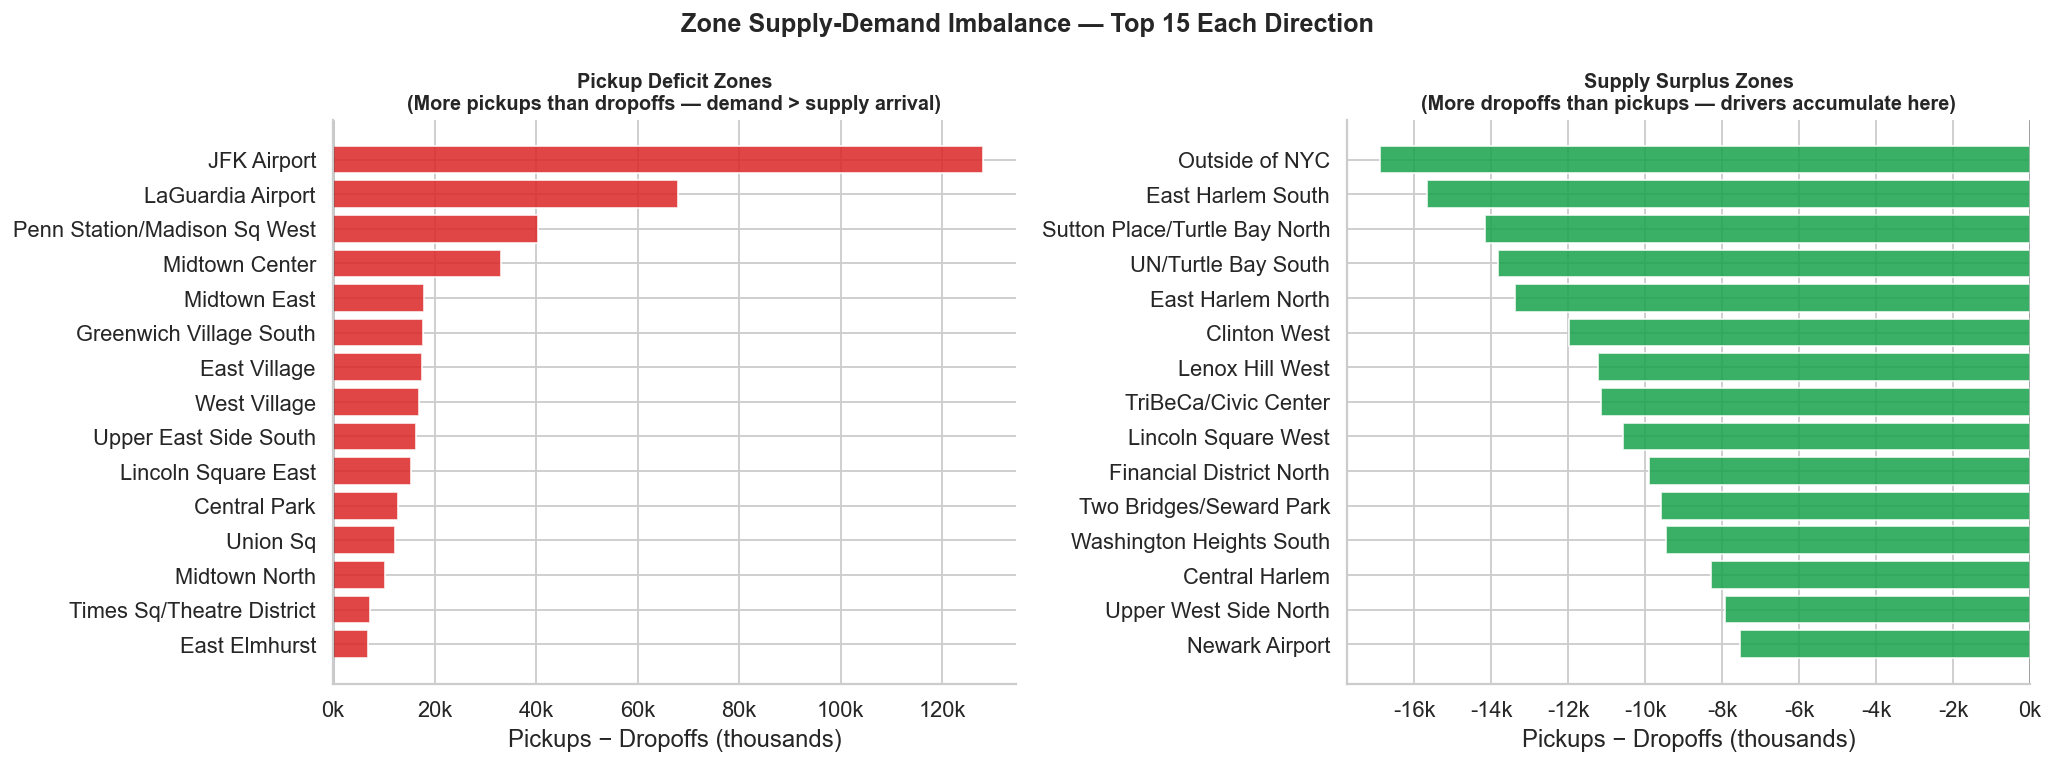

In [16]:
# ── Top imbalanced zones — the actionable output ──────────────────────────────
# We filter to zones with meaningful volume (top 50% by total trips)
# to avoid small zones with noisy ratios dominating the chart.

volume_threshold = zone_balance["total_volume"].quantile(0.5)
meaningful = zone_balance[zone_balance["total_volume"] >= volume_threshold].copy()

# Top 15 pickup-deficit zones (drivers needed here)
top_deficit = meaningful.nlargest(15, "imbalance")
# Top 15 supply-surplus zones (too many drivers, not enough demand)
top_surplus = meaningful.nsmallest(15, "imbalance")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Zone Supply-Demand Imbalance — Top 15 Each Direction",
             fontsize=14, fontweight="bold")

for ax, data, color, title, xlabel in [
    (axes[0], top_deficit, RED,   "Pickup Deficit Zones\n(More pickups than dropoffs — demand > supply arrival)",
     "Pickups − Dropoffs"),
    (axes[1], top_surplus, GREEN, "Supply Surplus Zones\n(More dropoffs than pickups — drivers accumulate here)",
     "Pickups − Dropoffs"),
]:
    ax.barh(data["Zone"], data["imbalance"] / 1_000,
            color=color, edgecolor="white", alpha=0.85)
    ax.set_xlabel(f"{xlabel} (thousands)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.invert_yaxis()
    ax.axvline(0, color="black", linewidth=0.8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))

plt.tight_layout()
plt.savefig("plots/nb3_06_zone_imbalance.png", bbox_inches="tight")
plt.show()

💡 **Finding:** The imbalance chart is the most operationally actionable output in this notebook. The left panel shows zones where **passengers are waiting** — more pickups than arriving drivers. The right panel shows where **drivers are idle** — more dropoffs than available passengers. A platform would use this map to:
- Apply surge pricing in deficit zones to attract more drivers
- Show driver-side prompts discouraging movement toward surplus zones
- Design incentive zones for underserved areas

The airport zones deserve special attention: they typically appear in the deficit column because passengers queue for pickups faster than drivers cycle through.

In [17]:
# ── Summary table — most imbalanced high-volume zones ─────────────────────────
# This is the version you'd present in a business review.

summary_table = (
    meaningful
    .assign(
        direction=lambda x: np.where(x["imbalance"] > 0, "Pickup Deficit", "Supply Surplus")
    )
    .sort_values("imbalance", key=abs, ascending=False)
    .head(20)
    [["Zone", "Borough", "pickups", "dropoffs", "imbalance", "imbalance_ratio", "direction"]]
    .rename(columns={
        "pickups":          "Pickups",
        "dropoffs":         "Dropoffs",
        "imbalance":        "Imbalance",
        "imbalance_ratio":  "Ratio",
        "direction":        "Type"
    })
)

print("Top 20 Most Imbalanced High-Volume Zones")
print("(Imbalance = Pickups − Dropoffs | Ratio normalised by total volume)")
print()
summary_table.to_string(index=False)

Top 20 Most Imbalanced High-Volume Zones
(Imbalance = Pickups − Dropoffs | Ratio normalised by total volume)



'                         Zone   Borough  Pickups  Dropoffs  Imbalance  Ratio           Type\n                  JFK Airport    Queens 160722.0   32606.0   128116.0  0.663 Pickup Deficit\n            LaGuardia Airport    Queens 104806.0   36819.0    67987.0  0.480 Pickup Deficit\n Penn Station/Madison Sq West Manhattan 125680.0   85243.0    40437.0  0.192 Pickup Deficit\n               Midtown Center Manhattan 175505.0  142334.0    33171.0  0.104 Pickup Deficit\n                 Midtown East Manhattan 123245.0  105385.0    17860.0  0.078 Pickup Deficit\n      Greenwich Village South Manhattan  58555.0   40763.0    17792.0  0.179 Pickup Deficit\n                 East Village Manhattan 103117.0   85602.0    17515.0  0.093 Pickup Deficit\n                 West Village Manhattan  84687.0   67732.0    16955.0  0.111 Pickup Deficit\n               Outside of NYC       NaN    832.0   17730.0   -16898.0 -0.910 Supply Surplus\n        Upper East Side South Manhattan 186837.0  170534.0    16303.0

---
## Section D Summary — Key Findings for README

Run the cell below to print your README-ready bullet points with real numbers.

In [18]:
# ── Compile README-ready findings ────────────────────────────────────────────

# Thanksgiving drop
tg_row = tgiving_week[tgiving_week["date"] == pd.Timestamp("2025-11-27").date()]
tg_pct = tg_row["pct_vs_baseline"].values[0] if len(tg_row) else "N/A"

# Weekend crossover hour
crossover_str = f"{crossover}:00" if 'crossover' in dir() and pd.notna(crossover) else "late evening"

# Top pickup zone
top_pu_zone = top_pu.iloc[0]["PU_Zone"]
top_pu_count = top_pu.iloc[0]["pickups"]

# Most imbalanced deficit zone
top_deficit_zone = top_deficit.iloc[0]["Zone"]
top_deficit_val  = top_deficit.iloc[0]["imbalance"]

# Most imbalanced surplus zone
top_surplus_zone = top_surplus.iloc[0]["Zone"]
top_surplus_val  = top_surplus.iloc[0]["imbalance"]

# Manhattan share
manhattan_pct = borough_pu[borough_pu["PU_Borough"]=="Manhattan"]["pct"].values
manhattan_pct_str = f"{manhattan_pct[0]:.1f}%" if len(manhattan_pct) else "N/A"

print("=" * 60)
print("NOTEBOOK 3 — README BULLET POINTS")
print("=" * 60)
print(f"""
Demand Patterns:
  • Weekday evening rush (4–7pm) is the single largest demand window;
    weekend demand overtakes weekday demand after {crossover_str}
  • Manhattan accounts for {manhattan_pct_str} of all November pickups
  • Top pickup zone: {top_pu_zone} ({top_pu_count:,} trips)

Thanksgiving Effect:
  • Thanksgiving Day demand: {tg_pct:+.1f}% vs same-weekday baseline
  • Demand shift — not just a drop — with adjacent days showing
    compensating movement in the opposite direction

Supply-Demand Imbalance:
  • {top_deficit_zone}: pickup deficit of {top_deficit_val:,} trips
    (chronic under-supply — surge pricing territory)
  • {top_surplus_zone}: supply surplus of {abs(top_surplus_val):,} trips
    (drivers accumulate here with low utilisation)
  • {(zone_balance['imbalance'] > 0).sum()} of {len(zone_balance)} zones
    show pickup deficits — the operational problem is concentrated,
    not distributed evenly across the city
""")
print("=" * 60)

NOTEBOOK 3 — README BULLET POINTS


ValueError: Unknown format code 'f' for object of type 'str'

---
## Next Steps

- `04_revenue_analysis.ipynb` — driver effective hourly rate by time and zone; airport premium quantified; tip determinants without ML
- `sql/business_questions.sql` — these zone imbalance queries translated into DuckDB SQL for the warehouse-ready version
- **Tableau dashboard** — View 1 will be a zone-level demand map built directly from the imbalance data computed here